In [1]:
# Importar bibliotecas

import tensorflow as tf
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Configurações de caminhos

MODEL_PATH = "C:/Matheus/tech_challenge_fase4/models/lstm_close_price.h5"
SCALER_PATH = "C:/Matheus/tech_challenge_fase4/models/scaler.pkl"
TEST_DATA_PATH = "C:/Matheus/tech_challenge_fase4/data/raw/AAPL.csv"

In [3]:
# Carregar modelo e scaler

import joblib

model = load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
print("Min:", scaler.min_)
print("Scale:", scaler.scale_)
print("Data min original:", scaler.data_min_)
print("Data max original:", scaler.data_max_)


Min: [-5.89366823]
Scale: [0.0267348]
Data min original: [220.44932556]
Data max original: [257.85375977]


In [4]:
# Carregar dados de teste

df_test = pd.read_csv(TEST_DATA_PATH)
# Ajuste a coluna de acordo com sua feature alvo
target_col = 'Close'
values = df_test[[target_col]].values

df_test = df_test.drop([0, 1]).reset_index(drop=True)
df_test[[target_col]] = df_test[[target_col]].astype(float)
values = df_test[[target_col]].values
print(values)

[[220.44932556]
 [224.50648499]
 [228.25537109]
 [227.75817871]
 [226.27653503]
 [230.0055542 ]
 [232.54129028]
 [230.48283386]
 [230.8507843 ]
 [233.68484497]
 [235.15655518]
 [234.54000854]
 [229.46855164]
 [229.27963257]
 [230.11494446]
 [232.09378052]
 [232.36228943]
 [228.81227112]
 [224.64570618]
 [221.6625061 ]
 [220.76751709]
 [222.19946289]
 [221.47355652]
 [226.20692444]
 [225.93814087]
 [223.22041321]
 [223.22041321]
 [224.10641479]
 [227.19244385]
 [223.98695374]
 [226.99336243]
 [227.25218201]
 [227.96896362]
 [227.49111938]
 [228.83502197]
 [231.8215332 ]
 [234.00166321]
 [233.87223816]
 [236.26144409]
 [238.51127625]
 [241.55747986]
 [241.91586304]
 [241.94573975]
 [241.74664307]
 [245.63902283]
 [246.6544342 ]
 [245.38021851]
 [246.84359741]
 [247.01281738]
 [249.909729  ]
 [252.33872986]
 [246.93319702]
 [248.66534424]
 [253.3441925 ]
 [254.1206665 ]
 [257.03747559]
 [257.85375977]
 [254.43922424]
 [251.06448364]
 [249.29251099]]


In [5]:
# Pré-processamento para LSTM

# Escalar os dados
values_scaled = scaler.transform(values)
print(values_scaled)

# Ajustar shape para LSTM: (samples, timesteps, features)
X_test_scaled = values_scaled.reshape((values_scaled.shape[0], 1, values_scaled.shape[1]))

[[0.        ]
 [0.10846734]
 [0.20869305]
 [0.19540071]
 [0.15578927]
 [0.25548384]
 [0.32327624]
 [0.26824382]
 [0.2780809 ]
 [0.35384894]
 [0.39319482]
 [0.37671157]
 [0.24112719]
 [0.23607648]
 [0.25840837]
 [0.31131215]
 [0.31849068]
 [0.22358166]
 [0.11218939]
 [0.03243414]
 [0.00850679]
 [0.04678957]
 [0.02738261]
 [0.15392824]
 [0.14674237]
 [0.07408447]
 [0.07408447]
 [0.09777154]
 [0.18027591]
 [0.09457778]
 [0.1749535 ]
 [0.18187299]
 [0.20103601]
 [0.18826094]
 [0.2241899 ]
 [0.30403368]
 [0.36231901]
 [0.35885886]
 [0.4227338 ]
 [0.48288261]
 [0.56432225]
 [0.57390355]
 [0.5747023 ]
 [0.56937949]
 [0.67344147]
 [0.70058829]
 [0.66652239]
 [0.70564553]
 [0.71016959]
 [0.78761794]
 [0.85255679]
 [0.70804096]
 [0.75434957]
 [0.87943763]
 [0.90019651]
 [0.97817681]
 [1.        ]
 [0.90871308]
 [0.81849007]
 [0.77111674]]


In [6]:
# Fazer previsões

y_pred_scaled = model.predict(X_test_scaled)

# Desescalar
y_pred = scaler.inverse_transform(y_pred_scaled)
print(y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
[[227.27379]
 [228.0352 ]
 [228.74709]
 [228.65224]
 [228.37036]
 [229.08205]
 [229.57011]
 [229.17365]
 [229.24437]
 [229.79128]
 [230.07683]
 [229.95708]
 [228.9791 ]
 [228.94292]
 [229.10301]
 [229.48373]
 [229.53555]
 [228.85349]
 [228.0615 ]
 [227.50044]
 [227.33315]
 [227.60106]
 [227.4651 ]
 [228.35713]
 [228.30615]
 [227.7928 ]
 [227.7928 ]
 [227.95969]
 [228.54446]
 [227.93716]
 [228.50659]
 [228.55583]
 [228.69243]
 [228.60133]
 [228.85785]
 [229.43124]
 [229.85268]
 [229.82758]
 [230.29189]
 [230.73148]
 [231.33015]
 [231.40083]
 [231.40672]
 [231.36745]
 [232.13812]
 [232.34007]
 [232.0867 ]
 [232.37775]
 [232.41145]
 [232.98993]
 [233.47702]
 [232.39558]
 [232.74109]
 [233.67915]
 [233.83545]
 [234.42398]
 [234.58905]
 [233.89963]
 [233.22127]
 [232.86644]]


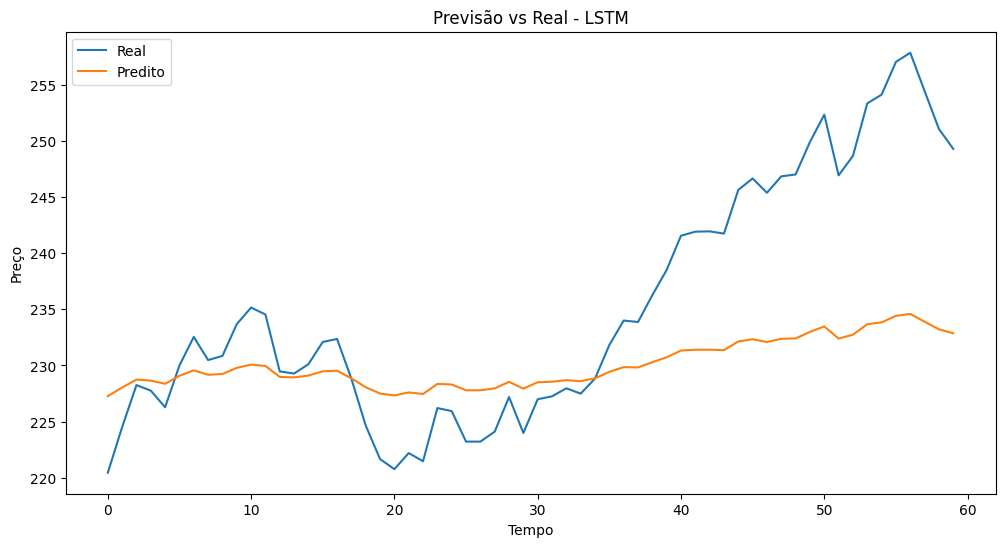

In [7]:
# Comparar previsões com valores reais

plt.figure(figsize=(12,6))
plt.plot(df_test[target_col].values, label='Real')
plt.plot(y_pred, label='Predito')
plt.title('Previsão vs Real - LSTM')
plt.xlabel('Tempo')
plt.ylabel('Preço')
plt.legend()
plt.show()

In [8]:
# Calcular métricas

mae = mean_absolute_error(df_test[target_col], y_pred)
rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))

print(f"MAE: {mae:.5f}")
print(f"RMSE: {rmse:.5f}")

MAE: 7.32117
RMSE: 9.93663


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
MAE: 7.32, RMSE: 9.94


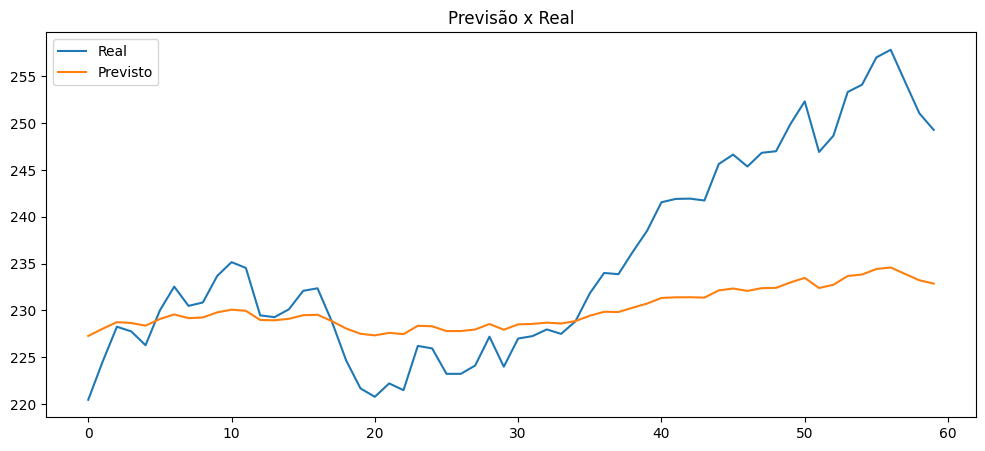

In [9]:
# -----------------------------
# CMD DE NOTEBOOK: VALIDAR SCALER E PREVISÃO
# -----------------------------

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Para o modelo Keras
from tensorflow.keras.models import load_model

# -----------------------------
# 1. Carregar scaler e modelo
# -----------------------------
scaler = joblib.load(SCALER_PATH)
model = load_model(MODEL_PATH)

# -----------------------------
# 2. Preparar dados de teste
# -----------------------------
# Suponha que df_test tenha a coluna 'Close'
X_test = df_test[['Close']].values  # precisa ser 2D

# -----------------------------
# 3. Transformar dados
# -----------------------------
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 4. Prever com o modelo
# -----------------------------
y_pred_scaled = model.predict(X_test_scaled)

# Certifique-se que está em 2D antes de inverter
if y_pred_scaled.ndim == 1:
    y_pred_scaled = y_pred_scaled.reshape(-1, 1)

# -----------------------------
# 5. Inverter escala
# -----------------------------
y_pred = scaler.inverse_transform(y_pred_scaled)

# -----------------------------
# 6. Clipping (opcional, previne extrapolação absurda)
# -----------------------------
y_pred = np.clip(y_pred, scaler.data_min_, scaler.data_max_)

# -----------------------------
# 7. Comparar com valores reais
# -----------------------------
y_true = df_test[['Close']].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# -----------------------------
# 8. Plot (opcional)
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_true, label='Real')
plt.plot(y_pred, label='Previsto')
plt.title("Previsão x Real")
plt.legend()
plt.show()
